# Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.interpolate import interp1d


# Custom Functions

In [2]:
def ForcingFunctionFM(P0, freq, c, DOF, duration, timemesh, fm=5.0, beta=2.0):
    """
    Pure frequency-modulated travelling acoustic wave used to simulate a sound wave propogating in 1D.
    This 1D pressure wave is evaluated at each membrane location to provide F(t) functions at those locations.
    The movement of the membranes do not create secondary waves and membranes are assumed acoustically transparent ie. the wave influences the membrane but the membrane does not influence the wave.

    Parameters
    ----------
    P0       : acoustic pressure amplitude (Pa)
    freq     : carrier frequency (Hz)
    c        : speed of sound in medium (m/s)
    DOF      : number of spatial DOFs, equal to the number of membranes used
    duration : total simulation time (s)
    timemesh : number of time steps, determines the time accuracy
    fm       : modulation frequency (Hz)
    beta     : modulation index (freq deviation = ± beta * fm Hz)

    Returns
    -------
    Ft : (timemesh, DOF) forcing array. Forcing function each membrane experiences independently
    t  : (timemesh,) time array. Output for the purpose of plotting
    """
    w_c = 2.0 * np.pi * freq    # circular frequencies
    w_m = 2.0 * np.pi * fm
    k   = w_c / c
    amp = np.pi * 0.15**2 * P0  # amplitude of forcing function considers the area on which the acoustic pressure variation is acting

    x = np.linspace(0, 1, DOF)
    t = np.linspace(0, duration, timemesh)

    phase = w_c * t + beta * np.sin(w_m * t)    # modulation frequency used to adjust the signal phase to simulate frequency modulation
    Ft = amp * np.cos(phase[:, None] - k * x[None, :])

    return Ft, t

def TaylorExpansion(gamma, s, V0, n_terms,P0):
    """
    Returns the coefficients c_k in the expansion: (1 - s*(x_n - x_{n-1})/V0)^(-gamma) = sum_{k=0}^{n} c_k * (x_n - x_{n-1})^k
    These terms correlate to the spring rates for the nonlinear spring assumption based on adiabatic compression

    Parameters
    ----------
    gamma   : exponent
    s       : cross-sectional area
    V0      : reference volume, volume of cavity at equilibrium
    n_terms : number of terms to return, number of terms used to approximate nonlinear spring
    P0      : the static air pressure in the cavity

    Returns
    -------
    coeffs  : array of length n_terms, where coeffs[k] multiplies (x_n - x_{n-1})^k
    """
    coeffs = np.zeros(n_terms)
    coeffs[0] = 1.0                 # k = 0 term is always 1
    for k in range(1, n_terms):     # Each coefficient builds on the previous: c_k = c_{k-1} * (gamma + k - 1) / k * (s / V0)
        coeffs[k] = coeffs[k - 1] * (gamma + k - 1) / k * (s / V0)
    return coeffs * s * P0          # multiplied by cavity pressure and cross-sectional area to directly output restoring force coefficients

def MassMat(DOF,mass):
    """
    Produces a diagonal mass matrix for MDOF system.

    Parameters
    ----------
    DOF      : number of spacial DOF
    mass     : mass of each membrane (kg)

    Returns
    -------
    M     : diagonal mass matrix
    """
    M = np.zeros((DOF,DOF))
    np.fill_diagonal(M,mass)
    return M

def InternalForces(y, DOF, kg, NonlinearK):
    """
    Calculates the internal force vector for each membrane for a given time step

    Parameters
    ----------
    y          : vector of displacement and velocity for use in RK4 algorithm
    DOF        : degress of freedom/number of membranes
    kg         : gasket spring rate
    NonlinearK : nonlinear spring coefficients for air spring model

    Returns
    -------
    f_int      : internal force vector shape(DOF)
    """
    x = y[:DOF]                                 # extracts displacements from RK4 vector
    x_ext = np.concatenate(([0.0], x, [0.0]))   # Pad x with zeros at both ends to represent fixed walls

    # Relative displacements to left and right neighbors
    dx_left  = x_ext[1:-1] - x_ext[:-2]   # x[i] - x[i-1]
    dx_right = x_ext[1:-1] - x_ext[2:]    # x[i] - x[i+1]

    f_int = kg * x                              # Ground spring
    
    for k, ck in enumerate(NonlinearK):         # Nonlinear air spring contributions
        p = k + 1
        f_int += ck * (dx_left**p + dx_right**p)
    return f_int

def equations_of_motion(t_val, y, M, DOF, kg, eta, omega, NonlinearK, F_interp):
    """
    Equation of motion of the vibrating system
    Converts the 2nd-order MDOF system to 1st-order form for use in RK4.
    Uses hysteresis damping: F = k(1 + iη)x

    Parameters
    ----------
    t_val       : current time index
    y           : RK4 vector of displacement and velocities
    M           : mass matrix
    DOF         : number of membranes
    kg          : gasket spring rate
    eta         : hysteresis loss factor
    omega       : carrier function circular frequency
    NonlinearK  : nonlinear spring coefficients for air spring model
    F_interp    : interpolated external forcing function to account for any mismatch in simulation accuracy

    Returns
    -------    
    State vector y = [x_0, ..., x_{n-1}, xdot_0, ..., xdot_{n-1}] for use in RK4
    Returns dy/dt  = [xdot_0, ..., xdot_{n-1}, xddot_0, ..., xddot_{n-1}] for plotting
    """
    x    = y[:DOF]                                      # extract displacement and velocity from RK4 vector
    xdot = y[DOF:]
    
    f_int = InternalForces(y, DOF, kg, NonlinearK)      # internal restoring forces (ground + nonlinear air springs)
    F_ext = F_interp(t_val)                             # external forces at given timestep
    
    f_damp = (eta * kg / omega) * xdot                  # Hysteresis damping force: equivalent viscous from F = k(1 + iη)x 
    
    xddot = np.linalg.solve(M, F_ext - f_int - f_damp)  # Accelerations: M * xddot = F_ext - f_int - f_damp
    return np.concatenate([xdot, xddot]),xddot

def solve_RK4(M, DOF, kg, eta, omega, NonlinearK, Ft, t):
    """
    Solves the MDOF system using Runge-Kutta 4 to extract displacement, velocity and acceleration data.

    Parameters
    ----------
    M          : mass matrix
    DOF        : number of membranes
    kg         : ground spring stiffness
    eta        : loss factor for hysteresis damping, coverted to approximate viscous damping
    omega      : excitation circular frequency (rad/s) of carrier wave
    nonlineark : array of nonlinear spring coefficients for air spring model
    Ft         : (n_timesteps, DOF) external force array
    t          : (n_timesteps,) time array
    Returns
    -------
    X    : (n_timesteps, DOF) displacement history
    Xdot : (n_timesteps, DOF) velocity history
    Xddot: (n_timesteps, DOF) acceleration history
    """
    n_steps = len(t)
    M_inv = np.linalg.inv(M)
    
    F_interp = interp1d(t, Ft, axis=0, kind='linear', fill_value='extrapolate') # Build a linear interpolator for the forcing function
    
    X    = np.zeros((n_steps, DOF))                                             # initialize output arrays
    Xdot = np.zeros((n_steps, DOF))
    Xddot = np.zeros((n_steps,DOF))
    
    y = np.zeros(2 * DOF)                                                       # Initial state: [displacements, velocities] = 0
    X[0]    = y[:DOF]
    Xdot[0] = y[DOF:]
    _,Xddot[0] = equations_of_motion(t[0],y,M,DOF,kg,eta,omega,NonlinearK=NonlinearK,F_interp=F_interp)

    for i in range(n_steps - 1):                                                # solves each timestep individually
        dt = t[i + 1] - t[i]
        
        # RK4 stages
        k1,_ = equations_of_motion(t[i], y, M_inv, DOF, kg, eta, omega, NonlinearK, F_interp)
        k2,_ = equations_of_motion(t[i] + dt / 2, y + dt/2 * k1, M_inv, DOF, kg, eta, omega, NonlinearK, F_interp)
        k3,_ = equations_of_motion(t[i] + dt / 2, y + dt/2 * k2, M_inv, DOF, kg, eta, omega, NonlinearK, F_interp)
        k4,_ = equations_of_motion(t[i] + dt, y + dt * k3, M_inv, DOF, kg, eta, omega, NonlinearK, F_interp)
        
        y = y + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)                              # Update state
        X[i + 1]    = y[:DOF]
        Xdot[i + 1] = y[DOF:]
        _,Xddot[i+1] = equations_of_motion(t[i+1],y,M,DOF,kg,eta,omega,NonlinearK=NonlinearK,F_interp=F_interp)
    return X, Xdot,Xddot

def CosineSimilarity(x1,x2):    # calculates the cosine simialrity between two different vectors

    xvec1 = np.reshape(x1,-1)
    xvec2 = np.reshape(x2,-1)

    x1bar = 1/len(xvec1)*sum(xvec1)
    x2bar = 1/len(xvec2)*sum(xvec2)

    x1sigma = sum((xvec1)**2)**0.5
    x2sigma = sum((xvec2)**2)**0.5

    return ((np.sum((xvec1)*(xvec2))/(x1sigma*x2sigma))**2)**0.5

def MeanWeightedCosineSimilarity(x1,x2):    # calculates the weighted cosine similarity between two different vectors

    xvec1 = np.reshape(x1,-1)
    xvec2 = np.reshape(x2,-1)

    x1bar = 1/len(xvec1)*sum(xvec1)
    x2bar = 1/len(xvec2)*sum(xvec2)

    x1sigma = sum((xvec1 - x1bar)**2)**0.5
    x2sigma = sum((xvec2 - x2bar)**2)**0.5

    return ((np.sum((xvec1-x1bar)*(xvec2-x2bar))/(x1sigma*x2sigma))**2)**0.5

# Model Verification

In [3]:
# Test 1: Zero forcing should yield zero displacement

# Arbitrary test parameters
DOF  = 7
mass = 1.0
kg   = 10.0
eta  = 0.1
omega_c = 2*np.pi*500

K = TaylorExpansion(gamma=1.4, s=np.pi*0.2**2, V0=np.pi*0.2**2/DOF, n_terms=3, P0=400000)
M = MassMat(DOF=DOF, mass=mass)
t = np.linspace(0, 0.05, 1000)
Ft_zero = np.zeros((len(t), DOF))

X, Xdot, Xddot = solve_RK4(M, DOF, kg, eta, omega_c, K, Ft_zero, t)
max_disp = np.max(np.abs(X))
print(X.shape)
print(f"Max displacement: {max_disp:.2e} m")
assert max_disp < 1e-12, "FAIL: nonzero response to zero forcing!"
print("PASS")

(1000, 7)
Max displacement: 0.00e+00 m
PASS


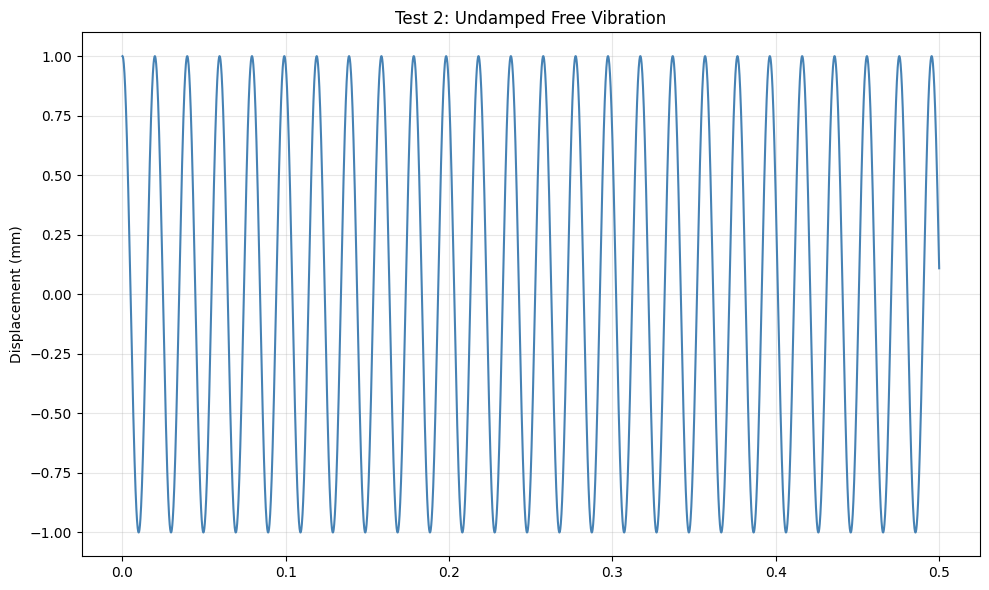

Displacement magnitude exactly as specified, does not decay, model is still working correctly


In [4]:
# Test 2: Energy conservation in undamped free vibration

DOF  = 1          # simplest case: single membrane
mass = 1.0
kg   = 10.0
eta  = 0.0        # no damping
omega_c = 2*np.pi*500
n_steps = 5000
duration = 0.5

# Linear spring only (n_terms=1)
s  = np.pi * 0.2**2
P0_cav = 400000
K_lin = TaylorExpansion(gamma=1.4, s=s, V0=s*1/DOF, n_terms=1, P0=P0_cav)
M2 = MassMat(DOF=DOF, mass=mass)


t = np.linspace(0, duration, n_steps)
Ft_zero = np.zeros((n_steps, DOF))
#--------- Solve RK4 function, outside loop, so that initial displacement can be changed -------------


M_inv = np.linalg.inv(M2)

F_interp = interp1d(t, Ft_zero, axis=0, kind='linear', fill_value='extrapolate') # Build a linear interpolator for the forcing function

X    = np.zeros((n_steps, DOF))                                             # initialize output arrays
Xdot = np.zeros((n_steps, DOF))
Xddot = np.zeros((n_steps,DOF))

x1_0 = 1e-3

y = np.array([x1_0,0.0])                                                       # Initial state: [displacements, velocities] = 0
X[0]    = y[:DOF]
Xdot[0] = y[DOF:]
_,Xddot[0] = equations_of_motion(t[0],y,M2,DOF,kg,eta,omega_c,NonlinearK=K_lin,F_interp=F_interp)

for i in range(n_steps - 1):                                                # solves each timestep individually
    dt = t[i + 1] - t[i]
    
    # RK4 stages
    k1,_ = equations_of_motion(t[i], y, M_inv, DOF, kg, eta, omega_c, K_lin, F_interp)
    k2,_ = equations_of_motion(t[i] + dt / 2, y + dt/2 * k1, M_inv, DOF, kg, eta, omega_c, K_lin, F_interp)
    k3,_ = equations_of_motion(t[i] + dt / 2, y + dt/2 * k2, M_inv, DOF, kg, eta, omega_c, K_lin, F_interp)
    k4,_ = equations_of_motion(t[i] + dt, y + dt * k3, M_inv, DOF, kg, eta, omega_c, K_lin, F_interp)
    
    y = y + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)                              # Update state
    X[i + 1]    = y[:DOF]
    Xdot[i + 1] = y[DOF:]
    _,Xddot[i+1] = equations_of_motion(t[i+1],y,M2,DOF,kg,eta,omega_c,NonlinearK=K_lin,F_interp=F_interp)

# -------- end RK4 ------------

fig, axes = plt.subplots(1, 1, figsize=(10, 6), sharex=True)
axes.plot(t, X[:,0]*1e3, color='steelblue')
axes.set_ylabel("Displacement (mm)")
axes.set_title("Test 2: Undamped Free Vibration")
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Displacement magnitude exactly as specified, does not decay, model is still working correctly")

  k_total   = 100540.96 N/m
  omega_n   = 317.08 rad/s  (50.47 Hz)
  zeta      = 0.000001  (underdamped)
  omega_d   = 317.08 rad/s
Max absolute error: 1.32e-11 m
         Relative error:     0.0000%


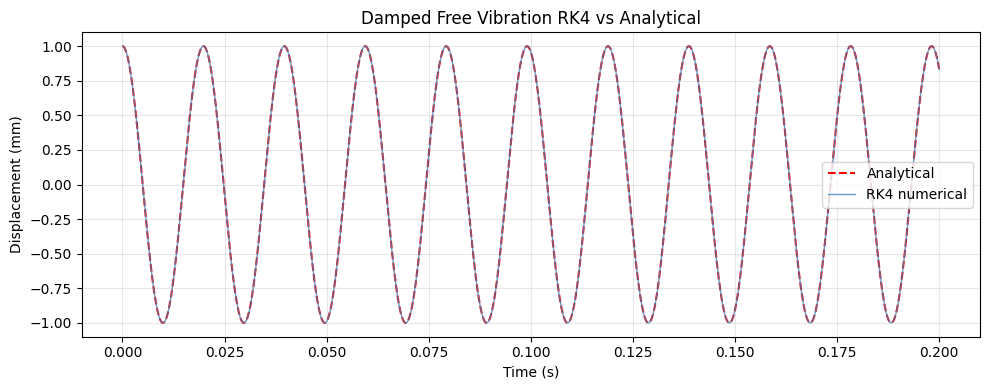

In [5]:
# Test 3: Damped free vibration vs analytical solution for linear springs and SDOF
DOF = 1
mass = 1.0
kg = 10.0
eta = 0.1
omega_c = 2*np.pi*500
s = np.pi*0.2**2
P0_cav = 400000
duration = 0.2
x0 = 1e-3
n_steps = 5000
t = np.linspace(0,duration,n_steps)

K_lin = TaylorExpansion(gamma=1.4, s=s, V0=s*1.0/DOF, n_terms=1, P0=P0_cav)
M3 = MassMat(DOF=DOF, mass=mass)

k_total = kg + 2*K_lin[0]           # total linear stiffness (kg + k_leftwall + k_rightwall)
c_eq = eta * kg / omega_c           # equivalent viscous damping coefficient (assuming constant frequency content)
omega_n = np.sqrt(k_total/mass)     # undamped natural frequency
zeta = c_eq / (2*mass*omega_n)      # damping ratio
omega_d = omega_n * np.sqrt(1 - zeta**2)    # damped natural frequency

print(f"  k_total   = {k_total:.2f} N/m")
print(f"  omega_n   = {omega_n:.2f} rad/s  ({omega_n/(2*np.pi):.2f} Hz)")
print(f"  zeta      = {zeta:.6f}  ({'underdamped' if zeta < 1 else 'overdamped'})")
print(f"  omega_d   = {omega_d:.2f} rad/s")

# ----------- RK4 solver, copy paste to edit initial displacement ------------

M_inv = np.linalg.inv(M3)
Ft_zero = np.zeros((n_steps, DOF))
F_interp = interp1d(t, Ft_zero, axis=0, kind='linear', fill_value='extrapolate') # Build a linear interpolator for the forcing function

X_num = np.zeros((n_steps, DOF))                                             # initialize output arrays
Xdot_num = np.zeros((n_steps, DOF))
Xddot_num = np.zeros((n_steps,DOF))

y = np.array([x0,0.0])                                                       # Initial state: [displacements, velocities] = 0
X_num[0]    = y[:DOF]
Xdot_num[0] = y[DOF:]
_,Xddot_num[0] = equations_of_motion(t[0],y,M3,DOF,kg,eta,omega_c,NonlinearK=K_lin,F_interp=F_interp)

for i in range(n_steps - 1):                                                # solves each timestep individually
    dt = t[i + 1] - t[i]
    
    # RK4 stages
    k1,_ = equations_of_motion(t[i], y, M_inv, DOF, kg, eta, omega_c, K_lin, F_interp)
    k2,_ = equations_of_motion(t[i] + dt / 2, y + dt/2 * k1, M_inv, DOF, kg, eta, omega_c, K_lin, F_interp)
    k3,_ = equations_of_motion(t[i] + dt / 2, y + dt/2 * k2, M_inv, DOF, kg, eta, omega_c, K_lin, F_interp)
    k4,_ = equations_of_motion(t[i] + dt, y + dt * k3, M_inv, DOF, kg, eta, omega_c, K_lin, F_interp)
    
    y = y + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)                              # Update state
    X_num[i + 1]    = y[:DOF]
    Xdot_num[i + 1] = y[DOF:]
    _,Xddot_num[i+1] = equations_of_motion(t[i+1],y,M3,DOF,kg,eta,omega_c,NonlinearK=K_lin,F_interp=F_interp)

# --------- end RK4 -----------

# Analytical solution
X_exact = x0 * np.exp(-zeta*omega_n*t) * (np.cos(omega_d*t) + (zeta*omega_n/omega_d)*np.sin(omega_d*t)) # from solution in Rao textbook


max_error = np.max(np.abs(X_num[:,0] - X_exact))
rel_error = max_error / x0
print(f"Max absolute error: {max_error:.2e} m")
print(f"         Relative error:     {rel_error*100:.4f}%")

plt.figure(figsize=(10, 4))
plt.plot(t, X_exact*1e3, 'r--', lw=1.5, label='Analytical')
plt.plot(t, X_num[:,0]*1e3,  color='steelblue', lw=1, alpha=0.8, label='RK4 numerical')
plt.xlabel("Time (s)")
plt.ylabel("Displacement (mm)")
plt.title("Damped Free Vibration RK4 vs Analytical")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


  Analytical steady-state amplitude: 1.4471e-08 m
  RK4 steady-state amplitude:        1.4533e-08 m
  Relative error:                    0.428%


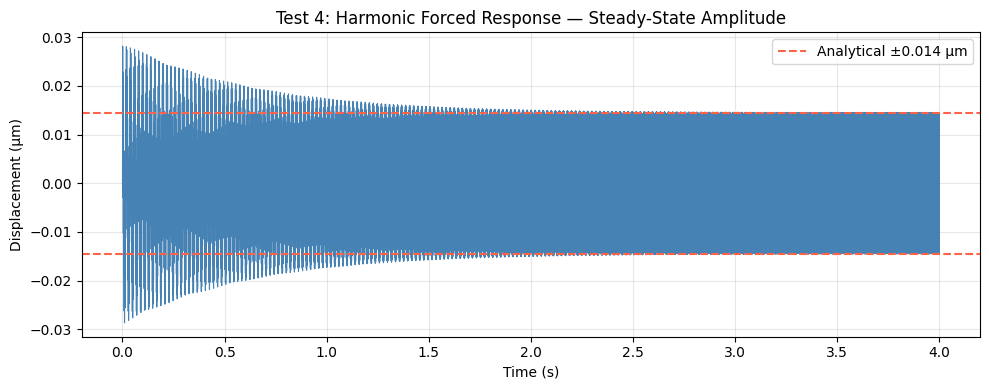

In [6]:
# ── Test 4: Harmonic forced response — steady-state amplitude ─────────────────
DOF   = 1
mass  = 1.0
kg    = 10.0
eta   = 1000    # artificaially large damping to get to steady state reponse in a reasonable number of timesteps
freq_carrier = 500.0          # carrier/excitation frequency (Hz)
omega_c = 2*np.pi*freq_carrier
s       = np.pi*0.2**2
P0_cav  = 400000
P0_acoustic = 2.0             # acoustic pressure amplitude (Pa)

K_lin = TaylorExpansion(gamma=1.4, s=s, V0=s*1.0/DOF, n_terms=1, P0=P0_cav)
M1    = MassMat(DOF=DOF, mass=mass)

k_total = kg + 2*K_lin[0]
c_eq    = eta * kg / omega_c

# Force amplitude at DOF=1, x=0:  amp*cos(omega_c*t - k*0) = amp*cos(omega_c*t)
amp = np.pi * 0.15**2 * P0_acoustic

# Analytical steady-state amplitude
X_analytic = amp / np.sqrt((k_total - mass*omega_c**2)**2 + (c_eq*omega_c)**2)  # derived from Rao
print(f"  Analytical steady-state amplitude: {X_analytic:.4e} m")

# Numerical: run long enough to reach steady state
n_steps  = 100000
duration = 4    # longer to allow transient to decay
t = np.linspace(0, duration, n_steps)

# Simple cosine forcing, no modulation
Ft_harmonic = amp * np.cos(omega_c * t)[:, None]

X, Xdot, Xddot = solve_RK4(M1, DOF, kg, eta, omega_c, K_lin, Ft_harmonic, t)

# Take peak amplitude from last 20% of signal (steady state)
steady_idx = int(0.8 * n_steps)
X_ss_num = (np.max(X[steady_idx:, 0]) - np.min(X[steady_idx:, 0])) / 2.0
rel_err   = abs(X_ss_num - X_analytic) / X_analytic
print(f"  RK4 steady-state amplitude:        {X_ss_num:.4e} m")
print(f"  Relative error:                    {rel_err*100:.3f}%")

plt.figure(figsize=(10, 4))
plt.plot(t, X[:,0]*1e6, color='steelblue', lw=0.8)
plt.axhline( X_analytic*1e6, color='tomato', ls='--', label=f'Analytical ±{X_analytic*1e6:.3f} μm')
plt.axhline(-X_analytic*1e6, color='tomato', ls='--')
plt.xlabel("Time (s)")
plt.ylabel("Displacement (μm)")
plt.title("Test 4: Harmonic Forced Response — Steady-State Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Sensitivity Analysis

In [7]:
#testing sensitivity to various parameters
#-----------------------------------------
# a baseline case which opperates only at the central modulation frequency is compared to a second case where a modulation frequency sweep is performed
# the second systems output is compared to the baseline for each input frequency using cosine similarity so that amplitude differences are recognised
# the parameters of interest are iterated in both systems so that they remain comparable, their influence is evaluated graphically

# changing the variable being studied is done by manually editing the code to iterate through different input parameters

#global parameters:

variable = np.array([0.1,0.2])
freqs = np.linspace(400,500,100,dtype=float)
sims = np.zeros((len(variable),len(freqs)),dtype=float)
print(variable)

#variations of parameters

for i,var in enumerate(variable):
    DOFbase = 7
    Kbase = TaylorExpansion(gamma=1.4, s=np.pi*0.2**2, V0=np.pi*0.2**2*1/DOFbase, n_terms=3,P0=400000)
    baselineFt, time = ForcingFunctionFM(P0=2.0, freq=500, c=343, DOF=DOFbase, duration=0.05, timemesh=1000, fm=450.0, beta=3.0)
    Mbase = MassMat(DOF=DOFbase, mass=1.0)
    _,_,base = solve_RK4(Mbase, DOF=DOFbase, kg=10, eta=var, omega=2*np.pi*500, NonlinearK=Kbase, Ft=baselineFt, t=time)
    for j,FM in enumerate(freqs):
        DOFvar = 7
        Kvar = TaylorExpansion(gamma=1.4, s=np.pi*0.2**2, V0=np.pi*0.2**2*1/DOFvar, n_terms=3,P0=400000)
        Ftvar, timevar = ForcingFunctionFM(P0=2.0, freq=500, c=343, DOF=DOFvar, duration=0.05, timemesh=1000, fm=FM, beta=3.0)
        Mvar = MassMat(DOF=DOFvar, mass=1.0)
        _,_,out = solve_RK4(Mvar, DOF=DOFvar, kg=10, eta=var, omega=2*np.pi*500, NonlinearK=Kbase, Ft=Ftvar, t=timevar)
        sims[i,j] = CosineSimilarity(base,out)
        print(f"variable {i+1} iteration {j+1} Complete")

[0.1 0.2]
variable 1 iteration 1 Complete
variable 1 iteration 2 Complete
variable 1 iteration 3 Complete
variable 1 iteration 4 Complete
variable 1 iteration 5 Complete
variable 1 iteration 6 Complete
variable 1 iteration 7 Complete
variable 1 iteration 8 Complete
variable 1 iteration 9 Complete
variable 1 iteration 10 Complete
variable 1 iteration 11 Complete
variable 1 iteration 12 Complete
variable 1 iteration 13 Complete
variable 1 iteration 14 Complete
variable 1 iteration 15 Complete
variable 1 iteration 16 Complete
variable 1 iteration 17 Complete
variable 1 iteration 18 Complete
variable 1 iteration 19 Complete
variable 1 iteration 20 Complete
variable 1 iteration 21 Complete
variable 1 iteration 22 Complete
variable 1 iteration 23 Complete
variable 1 iteration 24 Complete
variable 1 iteration 25 Complete
variable 1 iteration 26 Complete
variable 1 iteration 27 Complete
variable 1 iteration 28 Complete
variable 1 iteration 29 Complete
variable 1 iteration 30 Complete
variable 

maximum similarity achieved: 0.991984899625053
maximum similarity achieved: 0.991984873467436


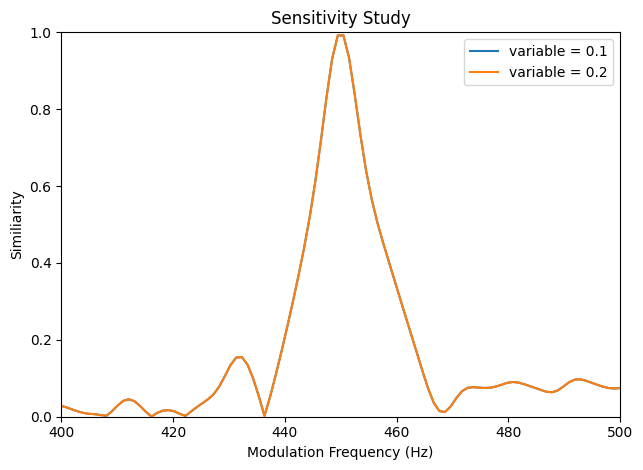

In [8]:
# plot the resulting similarity response functions overlayed on the same figure

plt.figure()        
for i in range(len(variable)):
    plt.plot(freqs, sims[i,:], label=f'variable = {variable[i]}')
    print(f"maximum similarity achieved: {max(sims[i,:])}")
plt.xlabel('Modulation Frequency (Hz)')
plt.ylabel('Similiarity')
plt.title('Sensitivity Study')
plt.legend()
plt.tight_layout()
plt.xlim(400,500)      # lock x-axis from 400 to 500
plt.ylim(0, 1) 
plt.show()

# Optimisation

In [9]:
def selectivity_objective(params, target_fm=450.0, freqs=np.linspace(400, 500, 100)):
    """
    Defines the function to be optimized
    Negative selectivity score (minimize this). To maximize the desired quantities.
    
    params = [DOF, mass, radius, pressure_Pa, beta] as identified by sensitivity study 
    
    Goals:
    1. High peak similarity near target_fm
    2. Wide peak (large area under the curve near target)
    3. Low off-peak values (small area far from target)
    """
    DOF = int(round(params[0]))
    mass = params[1]
    radius = params[2]
    pressure = params[3]
    beta = params[4]
    
    tmesh = 1000
    duration = 0.05
    
    K = TaylorExpansion(gamma=1.4, s=np.pi*radius**2, V0=np.pi*radius**2/DOF, n_terms=3, P0=pressure)
    M = MassMat(DOF, mass)
    
    # Baseline response at the target modulation frequency
    Ft_base, t_base = ForcingFunctionFM(P0=2.0, freq=500, c=343, DOF=DOF, duration=duration, timemesh=tmesh, fm=target_fm, beta=beta)
    _, _, base = solve_RK4(M, DOF=DOF, kg=10, eta=0.1, omega=2*np.pi*500, NonlinearK=K, Ft=Ft_base, t=t_base)
    
    # Calculates the freguency sweep through the system for the given input parameters and returns the similarity response function
    sims = np.zeros(len(freqs))
    for j, fm in enumerate(freqs):
        Ft_var, t_var = ForcingFunctionFM(P0=2.0, freq=500, c=343, DOF=DOF, duration=duration, timemesh=tmesh, fm=fm, beta=beta)
        _, _, out = solve_RK4(M, DOF=DOF, kg=10, eta=0.1, omega=2*np.pi*500, NonlinearK=K, Ft=Ft_var, t=t_var)
        sims[j] = CosineSimilarity(base, out)   # uses cosine similarity so that amplitude differences indicate different results, non-normallized similarity
    
    # --- Metrics ---
    peak_val = np.max(sims)                  # Goal 1: maximize this
    peak_idx = np.argmax(sims)
    
    # Width: count how wide the response is above some threshold (e.g., 50% of peak)
    threshold = 0.75 * peak_val
    width = np.sum(sims > threshold)          # Goal 2: maximize this
    
    # Off-peak: mean similarity outside the peak, should create a dissimilarity "floor"
    off_peak_mask = sims <= threshold
    if np.any(off_peak_mask):
        off_peak_mean = np.mean(sims[off_peak_mask])  # Goal 3: minimize this
    else:
        off_peak_mean = threshold   # when no values fall below the disimilarity threshold it means they are all above it, penalize this harshly
    
    # Combined score (maximize): high peak, wide peak, low off-peak
    # Weight the different metrics to obtain optimum results (3 runs were performed, these are the weights for the similarity response function identified as optimum graphically)
    w_peak = 1.0        # weight for peak height
    w_width = 0.01      # weight for width
    w_offpeak = 10.0    # weight for suppressing off-peak
    
    score = w_peak * peak_val + w_width * width - w_offpeak * off_peak_mean # calculate the final score for a given set of parameters
    
    print(f"DOF={DOF}, mass={mass:.2f}, r={radius:.3f}, P={pressure:.0f}, "
          f"beta={beta:.1f} -> peak={peak_val:.4f}, width={width}, "
          f"off_peak={off_peak_mean:.4f}, score={score:.4f}")
    
    return -score  # negative because differential_evolution minimizes the function values


# Parameter bounds: [DOF, mass, radius, pressure, beta], chosen to define a feasible design space
boundaries = [
    (2, 10),           # DOF (will be rounded to int)
    (0.1, 5.0),        # mass
    (0.05, 0.5),       # radius
    (10000, 500000),   # pressure (Pa)
    (1.0, 10.0),       # beta
]

def de_callback(xk, convergence):
    de_callback.iteration += 1
    print(f"Iteration {de_callback.iteration}, convergence={convergence:.6f}, best params={xk}")


de_callback.iteration = 0

result = opt.differential_evolution(    # run differential evolution algorithm, popsize and maxiter limited due to time constraints
    func=selectivity_objective,
    bounds=boundaries,
    seed=69,           # nice
    maxiter=50,
    tol=1e-4,
    popsize=10,
    disp=True,
    callback=de_callback
)

print(f"\nOptimal parameters: {result.x}")
print(f"Best score: {-result.fun:.4f}")

DOF=9, mass=1.51, r=0.333, P=410626, beta=5.8 -> peak=0.9436, width=2, off_peak=0.1333, score=-0.3692


KeyboardInterrupt: 

# Data Reduction

In [10]:
ideal_case = {"DOF": 6,  "mass": 1.76, "r": 0.121, "P": 402884, "beta": 2.0, "peak": 0.9973, "width": 10, "off_peak": 0.1422, "score": 0.8129}

In [11]:
# Fixed simulation parameters

FREQ      = 500
C         = 343
DURATION  = 0.05
TIMEMESH  = 1000
FM_BASE   = 450.0
KG        = 10
ETA       = 0.1
GAMMA     = 1.4
N_TERMS   = 3
P0_FORCE  = 2.0
OMEGA     = 2.0 * np.pi * FREQ

freqs = np.linspace(400, 500, 100, dtype=float)

# ── Ideal case simulation ─────────────────────────────────────────────────────

DOF  = ideal_case["DOF"]
mass = ideal_case["mass"]
r    = ideal_case["r"]
P    = ideal_case["P"]
beta = ideal_case["beta"]

s  = np.pi * r**2
V0 = s * (1.0 / DOF)
K  = TaylorExpansion(gamma=GAMMA, s=s, V0=V0, n_terms=N_TERMS, P0=P)
M  = MassMat(DOF=DOF, mass=mass)

# Baseline simulation at FM_BASE
Ft_base, t_base = ForcingFunctionFM(
    P0=P0_FORCE, freq=FREQ, c=C, DOF=DOF,
    duration=DURATION, timemesh=TIMEMESH, fm=FM_BASE, beta=beta)
_, _, base_acc = solve_RK4(
    M, DOF=DOF, kg=KG, eta=ETA, omega=OMEGA,
    NonlinearK=K, Ft=Ft_base, t=t_base)

# Frequency sweep
sims = np.zeros(len(freqs))
for j, fm in enumerate(freqs):
    Ft_var, t_var = ForcingFunctionFM(
        P0=P0_FORCE, freq=FREQ, c=C, DOF=DOF,
        duration=DURATION, timemesh=TIMEMESH, fm=fm, beta=beta)
    _, _, out_acc = solve_RK4(
        M, DOF=DOF, kg=KG, eta=ETA, omega=OMEGA,
        NonlinearK=K, Ft=Ft_var, t=t_var)
    sims[j] = CosineSimilarity(base_acc, out_acc)

print(f"\nPeak similarity: {np.max(sims):.4f} at fm = {freqs[np.argmax(sims)]:.1f} Hz")


Peak similarity: 0.9972 at fm = 450.5 Hz


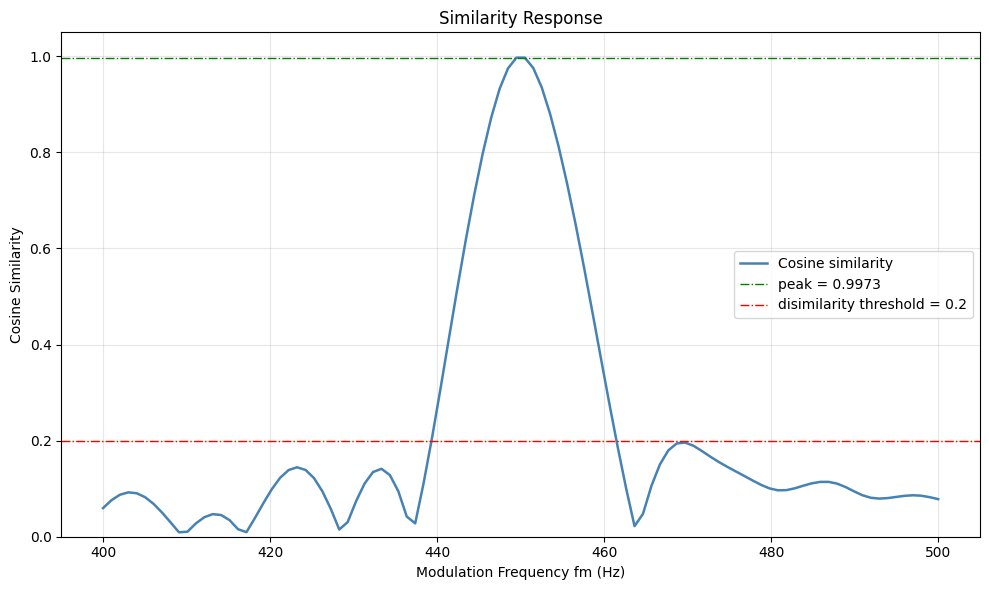

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(freqs, sims, color='steelblue', lw=1.8, label='Cosine similarity')
ax.axhline(ideal_case["peak"],     color='green', ls='-.', lw=1, label=f'peak = {ideal_case["peak"]:.4f}')
ax.axhline(0.2, color='red', ls='-.', lw=1, label=f'disimilarity threshold = 0.2')
ax.set_xlabel("Modulation Frequency fm (Hz)")
ax.set_ylabel("Cosine Similarity")
ax.set_title(f"Similarity Response")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

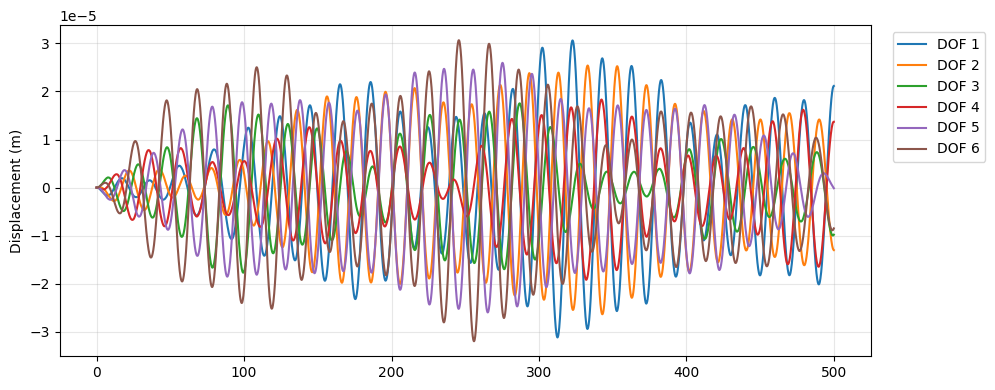

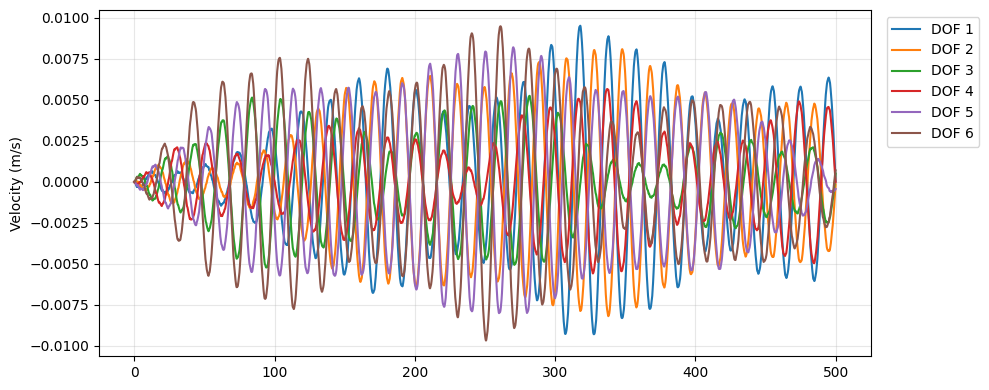

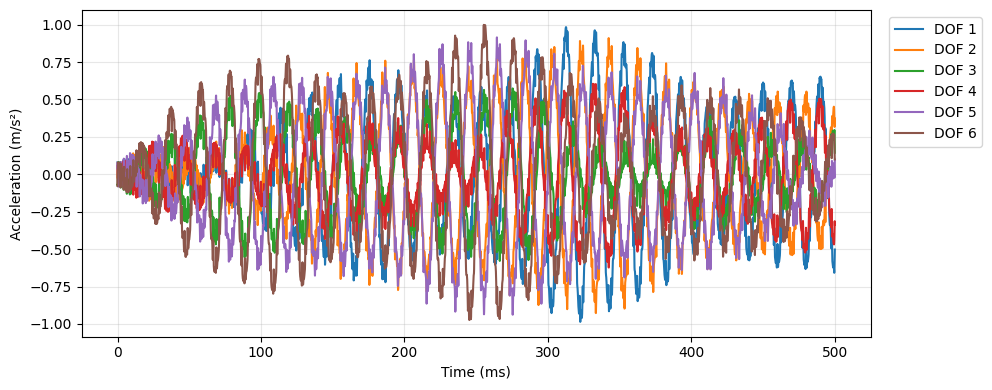

In [13]:
# --- ADJUSTABLE PARAMETERS ---
P0_FORCE_ADJ = 2    # Acoustic pressure amplitude (Pa)
KG_ADJ = 25      # Gasket (ground) spring rate (N/m)
FREQ = 500
C = 343
DURATION = 0.5
TIMEMESH = 5000
FM_BASE = 450.0
KG = 10
ETA = 0.1
GAMMA = 1.4
N_TERMS = 3
P0_FORCE = 2.0
OMEGA = 2.0 * np.pi * FREQ

# 1. Calculate intermediate variables
c2_s = np.pi * ideal_case['r']**2
c2_V0 = c2_s * (1.0 / ideal_case['DOF'])
c2_K = TaylorExpansion(gamma=GAMMA, s=c2_s, V0=c2_V0, n_terms=N_TERMS, P0=ideal_case['P'])
c2_M = MassMat(DOF=ideal_case['DOF'], mass=ideal_case['mass'])

# 2. Build the forcing function using the adjustable acoustic pressure
Ft_case2, t_case2 = ForcingFunctionFM(
    P0=P0_FORCE_ADJ, freq=FREQ, c=C, DOF=ideal_case['DOF'],
    duration=DURATION, timemesh=TIMEMESH, fm=FM_BASE, beta=ideal_case['beta']
)

# 3. Solve equations of motion using the adjustable gasket spring rate
X_case2, Xdot_case2, Xddot_case2 = solve_RK4(
    c2_M, DOF=ideal_case['DOF'], kg=KG_ADJ, eta=ETA, omega=OMEGA,
    NonlinearK=c2_K, Ft=Ft_case2, t=t_case2
)

# --- Plotting ---
# Convert time to milliseconds for cleaner x-axis
t_ms = t_case2 * 1000 

# Plot 1: Displacement
plt.figure(figsize=(10, 4))
for i in range(ideal_case['DOF']):
    label_str = f'DOF {i+1}'
    plt.plot(t_ms, X_case2[:, i], label=label_str)
plt.ylabel('Displacement (m)')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

# Plot 2: Velocity
plt.figure(figsize=(10, 4))
for i in range(ideal_case['DOF']):
    label_str = f'DOF {i+1}'
    plt.plot(t_ms, Xdot_case2[:, i], label=label_str)
plt.ylabel('Velocity (m/s)')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

# Plot 3: Acceleration
plt.figure(figsize=(10, 4))
for i in range(ideal_case['DOF']):
    label_str = f'DOF {i+1}'
    plt.plot(t_ms, Xddot_case2[:, i], label=label_str)
plt.ylabel('Acceleration (m/s²)')
plt.xlabel('Time (ms)')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()



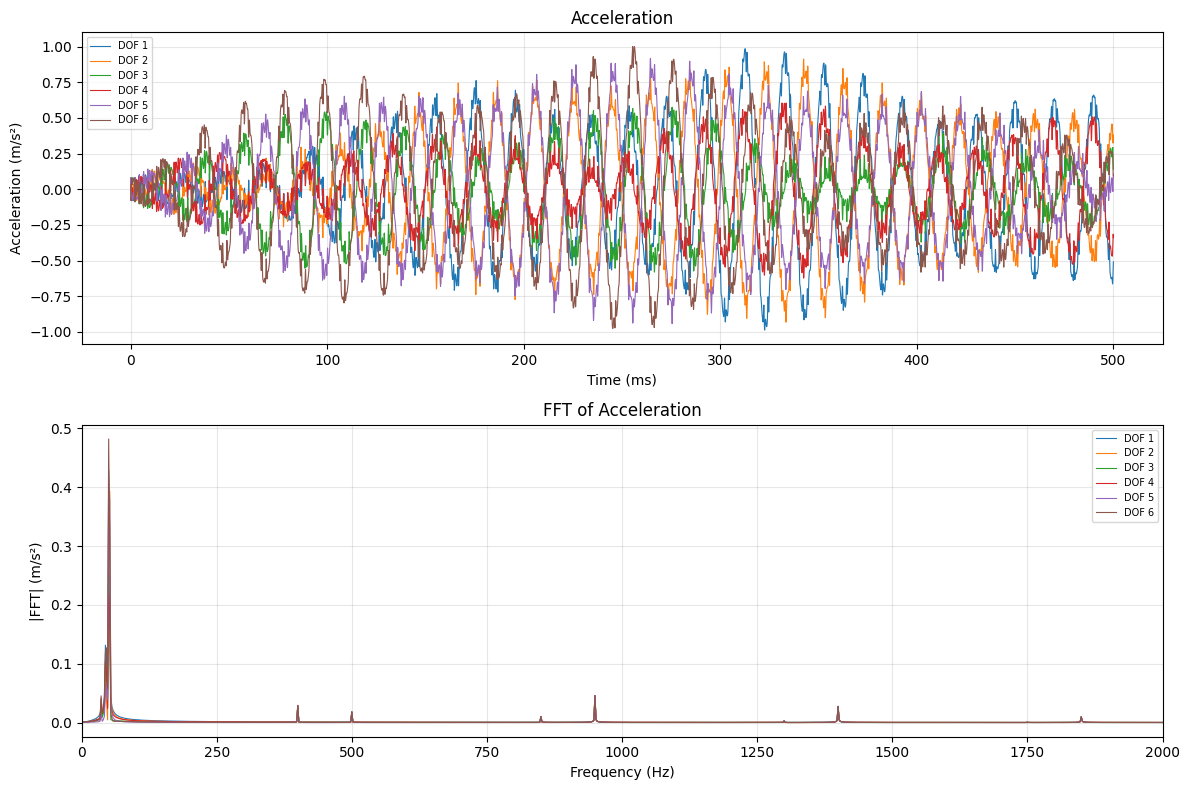

In [14]:
# FFT of Acceleration – All DOFs overlaid
DOF_  = ideal_case["DOF"]
mass_ = ideal_case["mass"]
r_    = ideal_case["r"]
P_    = ideal_case["P"]
beta_ = ideal_case["beta"]

s_  = np.pi * r_**2
V0_ = s_ * (1.0 / DOF_)
K_  = TaylorExpansion(gamma=GAMMA, s=s_, V0=V0_, n_terms=N_TERMS, P0=P_)

Ft_, t_ = ForcingFunctionFM(
    P0=P0_FORCE, freq=FREQ, c=C, DOF=DOF_,
    duration=DURATION, timemesh=TIMEMESH, fm=FM_BASE, beta=beta_)

M_ = MassMat(DOF=DOF_, mass=mass_)
X_, Xdot_, Xddot_ = solve_RK4(
    M_, DOF=DOF_, kg=KG, eta=ETA, omega=OMEGA,
    NonlinearK=K_, Ft=Ft_, t=t_)

dt = t_[1] - t_[0]
fs = 1.0 / dt
N  = len(t_)
freq_axis = np.fft.fftfreq(N, d=dt)[:N // 2]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for dof in range(DOF_):
    acc = Xddot_[:, dof]

    # Time domain
    axes[0].plot(t_ * 1000, acc, linewidth=0.8, label=f'DOF {dof+1}')

    # FFT
    fft_mag = np.abs(np.fft.fft(acc)) / N
    fft_ss  = 2.0 * fft_mag[:N // 2]
    axes[1].plot(freq_axis, fft_ss, linewidth=0.8, label=f'DOF {dof+1}')

axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Acceleration (m/s²)')
axes[0].set_title(f'Acceleration')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('|FFT| (m/s²)')
axes[1].set_title(f'FFT of Acceleration')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 2000)  # uncomment to zoom

plt.tight_layout()
plt.show()
